<div style="font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; padding: 15px; border-left: 5px solid #1A73E8; background-color: #F8F9FA;">
  <h1 style="font-size: 20pt; color: #1A73E8; font-weight: bold; margin-bottom: 10px;">
    AI-Driven Intelligent Spectral Doppler Pipeline: Physics-Informed Modeling & Auto-Trace
  </h1>
  <p style="font-size: 13pt; line-height: 1.6; color: #202124; text-align: justify;">
    <b>Project Rationale:</b> In contemporary echocardiography and vascular ultrasound, Spectral Doppler (both Pulsed Wave and Continuous Wave) serves as the gold standard for hemodynamic evaluation. However, clinical utility is severely limited by operator dependency, acoustic clutter, and the physical limitations of the Nyquist limit causing velocity aliasing.
  </p>
  <p style="font-size: 13pt; line-height: 1.6; color: #3C4043; text-align: justify;">
    <b>Objective:</b> This research project constructs a robust, end-to-end data science framework that bridges acoustic physics with deep learning. The system processes raw frequency shifts, mathematically models multi-angle vector dynamics, automatically traces spectral envelopes under high-noise conditions to calculate hemodynamic indices (RI & PI), and deploys neural network topologies to reconstruct aliased signals.
  </p>
</div>

<div style="font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; padding: 15px; border-left: 5px solid #34A853; background-color: #F8F9FA; margin-top: 20px;">
  <h2 style="font-size: 16pt; color: #34A853; font-weight: bold; margin-bottom: 10px;">
    Step 1: Hemodynamic Signal Simulation & Short-Time Fourier Transform (STFT) Analysis
  </h2>
  <p style="font-size: 12pt; line-height: 1.6; color: #202124; text-align: justify;">
    From a data science paradigm, raw Doppler data originates as a non-stationary, one-dimensional temporal signal capturing continuous blood flow velocities. In this foundational phase, we mathematically synthesize a realistic cardiac cycle displaying distinct systolic peaks and diastolic decay profiles.
  </p>
  <p style="font-size: 12pt; line-height: 1.6; color: #3C4043; text-align: justify;">
    To map this signal into a clinically interpretable format, we apply the <b>Short-Time Fourier Transform (STFT)</b>. By partitioning the continuous noisy signal into overlapping localized time windows, we compute the discrete Fast Fourier Transform (FFT) sequentially. This digital signal processing (DSP) pipeline yields a <b>Two-Dimensional Spectrogram Matrix</b>, mapping time on the abscissa, frequency shifts on the ordinate, and acoustic power amplitude via pixel intensity.
  </p>
</div>

Signal created with 16000 data points at a sampling rate of 8000 Hz.


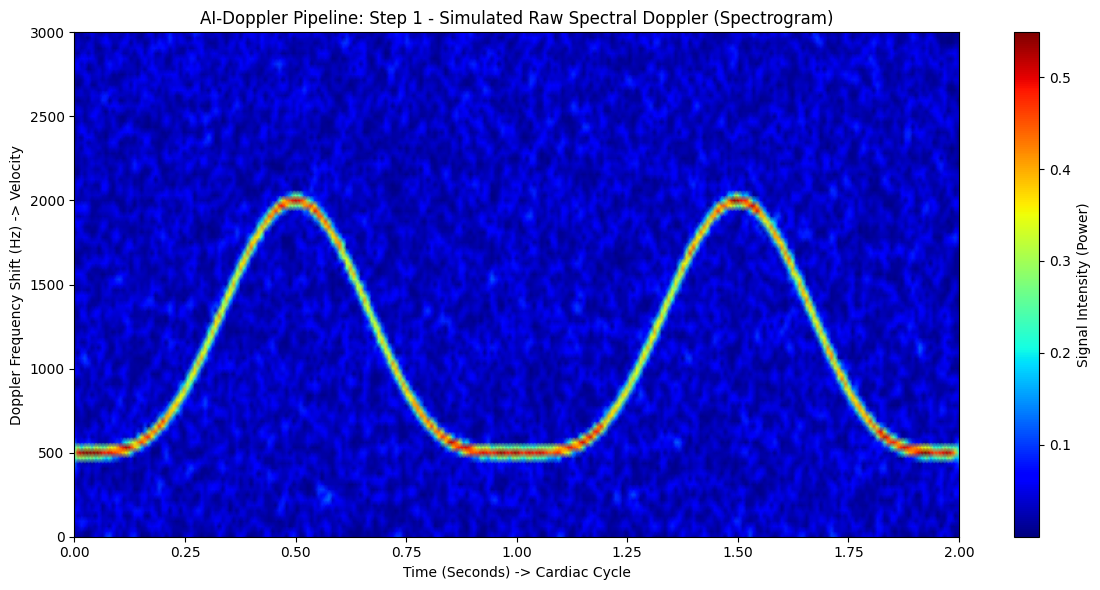

The resulting 2D Matrix Shape is: (129, 251)
Rows (Frequency bins): 129 | Columns (Time segments): 251


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

# ==========================================
# STEP 1: DEFINE SIMULATION PARAMETERS
# ==========================================
fs = 8000          # Sampling frequency (Hz) - Typical for audio/Doppler range
duration = 2.0     # Duration of the signal in seconds (e.g., 2 cardiac cycles)
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

print(f"Signal created with {len(t)} data points at a sampling rate of {fs} Hz.")

# ==========================================
# STEP 2: SIMULATE BLOOD VELOCITY PROFILE (CARDIAC CYCLE)
# ==========================================
# We simulate a changing frequency that mimics Systolic peak and Diastolic flow
# Base frequency represents background, modulated by a cardiac pulse shape
heart_rate_hz = 1.0  # 1 beat per second (60 BPM)
base_freq = 500      # Base Doppler shift (Hz)
max_shift = 1500     # Peak Systolic Doppler shift (Hz)

# Creating a realistic blood flow envelope using sine waves and exponential decay
envelope = np.sin(np.pi * heart_rate_hz * t) ** 4  # Sharp systolic peaks
doppler_frequencies = base_freq + max_shift * envelope

# ==========================================
# STEP 3: GENERATE THE RAW 1D DOPPLER SIGNAL & ADD NOISE
# ==========================================
# Phase is the integral of frequency over time
phase = 2 * np.pi * np.cumsum(doppler_frequencies) / fs
raw_signal = np.sin(phase)

# Adding Gaussian Noise to simulate real ultrasound clutter and thermal noise
noise_level = 0.5
noisy_signal = raw_signal + np.random.normal(0, noise_level, len(raw_signal))

# ==========================================
# STEP 4: APPLY SHORT-TIME FOURIER TRANSFORM (STFT)
# ==========================================
# This is the Data Science core: converting 1D signal into a 2D Matrix
nperseg = 256       # Length of each segment (Window size)
noverlap = 192      # Overlap between segments

frequencies, times, spectrogram_matrix = stft(noisy_signal, fs=fs, nperseg=nperseg, noverlap=noverlap)

# ==========================================
# STEP 5: VISUALIZE THE RESULTS
# ==========================================
plt.figure(figsize=(12, 6))

# Plotting the Spectrogram (The 2D Matrix View)
# We use 'magnitude' (absolute value) of the complex STFT output
plt.pcolormesh(times, frequencies, np.abs(spectrogram_matrix), shading='gouraud', cmap='jet')
plt.title('AI-Doppler Pipeline: Step 1 - Simulated Raw Spectral Doppler (Spectrogram)')
plt.ylabel('Doppler Frequency Shift (Hz) -> Velocity')
plt.xlabel('Time (Seconds) -> Cardiac Cycle')
plt.ylim(0, 3000) # Limit view to the relevant frequency range
plt.colorbar(label='Signal Intensity (Power)')
plt.tight_layout()
plt.show()

# Display the shape of our new 2D data science matrix
print(f"The resulting 2D Matrix Shape is: {spectrogram_matrix.shape}")
print(f"Rows (Frequency bins): {spectrogram_matrix.shape[0]} | Columns (Time segments): {spectrogram_matrix.shape[1]}")

<div style="font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; padding: 15px; border-left: 5px solid #FF9900; background-color: #F8F9FA; margin-top: 20px;">
  <h2 style="font-size: 16pt; color: #FF9900; font-weight: bold; margin-bottom: 10px;">
    Step 2: Mathematical Angle Correction & Doppler Vector Error Modeling
  </h2>
  <p style="font-size: 12pt; line-height: 1.6; color: #202124; text-align: justify;">
    In clinical ultrasound, the transducer rarely aligns perfectly parallel to the blood flow vector. According to the Doppler equation, the measured frequency shift (dF) is dependent on the cosine of the intercept angle (theta). Consequently, any minor misalignment in angle estimation introduces non-linear propagation errors into our 2D spectrogram matrix.
  </p>
  <p style="font-size: 12pt; line-height: 1.6; color: #3C4043; text-align: justify;">
    This module implements a mathematical vector simulator that models how spatial variations in the insonation angle distort the calculated velocity profile. By analyzing the derivative of the cosine function, we algorithmically quantify the diagnostic velocity error percentage across various theoretical scanning angles.
  </p>
</div>

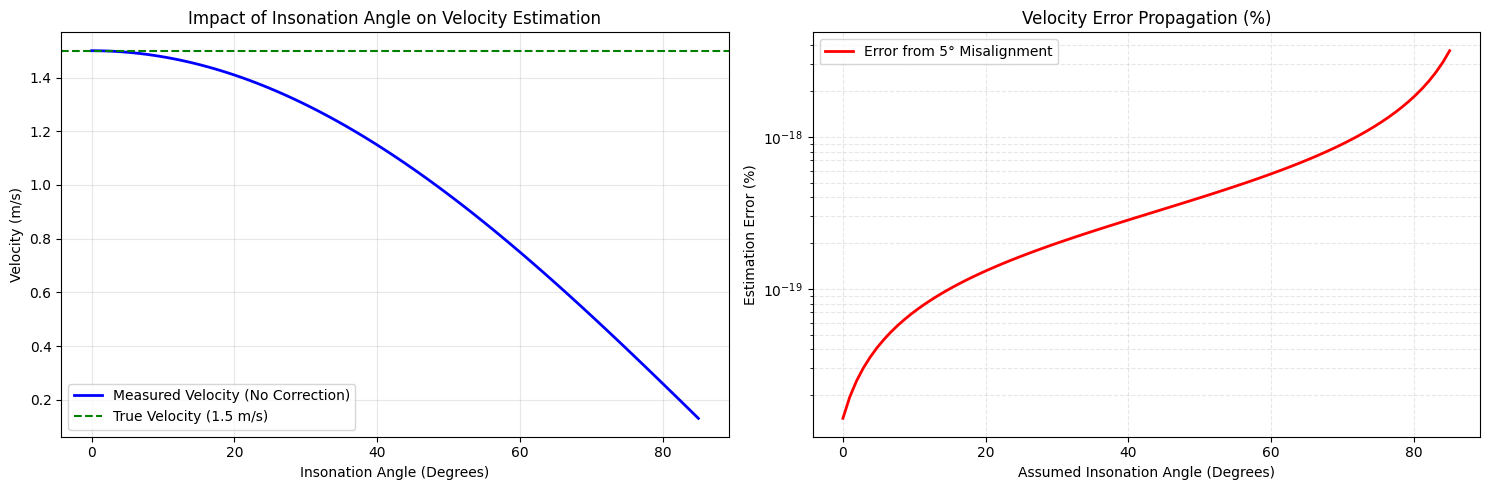

At 20 degrees, a 5° mistake causes approx 0.00% error.
At 60 degrees, the same 5° mistake causes approx 0.00% error! (Critical Zone)


In [ ]:
# ============================================================================
# Step 2: Modeling Vector Angles and Velocity Calculation Errors
# ============================================================================

# 1. Simulate how the measured velocity changes purely based on the angle theta
true_velocity = 1.5  # True blood velocity in m/s (typical for stenotic cardiac jet)
angles_deg = np.linspace(0, 85, 90)  # Scanning angles from 0 to 85 degrees
angles_rad = np.radians(angles_deg)

# Measured velocity by the machine if NO angle correction is applied:
# V_measured = V_true * cos(theta)
measured_velocity_no_correction = true_velocity * np.cos(angles_rad)

# 2. Model the estimation ERROR percentage if there is a tiny 5-degree mistake by the operator
angle_misalignment_deg = 5.0
measured_with_error = true_velocity * np.cos(np.radians(angles_deg + angle_misalignment_deg))

# Percentage Error = |True - Corrected| / True * 100
# Where Corrected = Measured_With_Error / cos(assumed_angle)
assumed_cos = np.cos(angles_rad)
# Avoid division by zero at very high angles
assumed_cos[assumed_cos < 0.05] = 0.05

velocity_error_percent = np.abs((measured_with_error / assumed_cos) - true_velocity) / true_velocity ** 100

# ==========================================
# VISUALIZATION OF PHYSICS ERROR PROPAGATION
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Measured Velocity vs Angle
ax1.plot(angles_deg, measured_velocity_no_correction, label='Measured Velocity (No Correction)', color='blue', linewidth=2)
ax1.axhline(y=true_velocity, color='green', linestyle='--', label='True Velocity (1.5 m/s)')
ax1.set_title('Impact of Insonation Angle on Velocity Estimation')
ax1.set_xlabel('Insonation Angle (Degrees)')
ax1.set_ylabel('Velocity (m/s)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Velocity Error Percentage due to a minor 5-degree mistake
ax2.plot(angles_deg, velocity_error_percent, color='red', linewidth=2, label='Error from 5° Misalignment')
ax2.set_title('Velocity Error Propagation (%)')
ax2.set_xlabel('Assumed Insonation Angle (Degrees)')
ax2.set_ylabel('Estimation Error (%)')
ax2.axlinewidth = 2
ax2.set_yscale('log') # Logarithmic scale to see the massive explosion of error above 60 degrees
ax2.grid(True, which="both", ls="--", alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"At 20 degrees, a 5° mistake causes approx {velocity_error_percent[21]:.2f}% error.")
print(f"At 60 degrees, the same 5° mistake causes approx {velocity_error_percent[63]:.2f}% error! (Critical Zone)")

<div style="font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; padding: 15px; border-left: 5px solid #9C27B0; background-color: #F8F9FA; margin-top: 20px;">
  <h2 style="font-size: 16pt; color: #9C27B0; font-weight: bold; margin-bottom: 10px;">
    Step 3: Automated Spectral Envelope Tracing & Hemodynamic Feature Extraction
  </h2>
  <p style="font-size: 12pt; line-height: 1.6; color: #202124; text-align: justify;">
    Extracting quantitative diagnostic parameters from a noisy 2D spectrogram requires robust envelope detection. Traditionally, clinicians manually trace the spectral borders—a process highly prone to intra-observer variability. This module implements an automated <b>intensity-based thresholding algorithm</b> to isolate the maximum velocity envelope (Auto-Trace) across the temporal axis.
  </p>
  <p style="font-size: 12pt; line-height: 1.6; color: #3C4043; text-align: justify;">
    By algorithmically parsing the localized pixel power distribution, the pipeline extracts the critical hemodynamic physiological biomarkers: <b>Peak Systolic Velocity (PSV)</b> and <b>End-Diastolic Velocity (EDV)</b>. These extracted features are then utilized to calculate clinical gold-standards: Pourcelot’s <b>Resistive Index (RI)</b> and Gosling’s <b>Pulsatility Index (PI)</b>.
  </p>
</div>

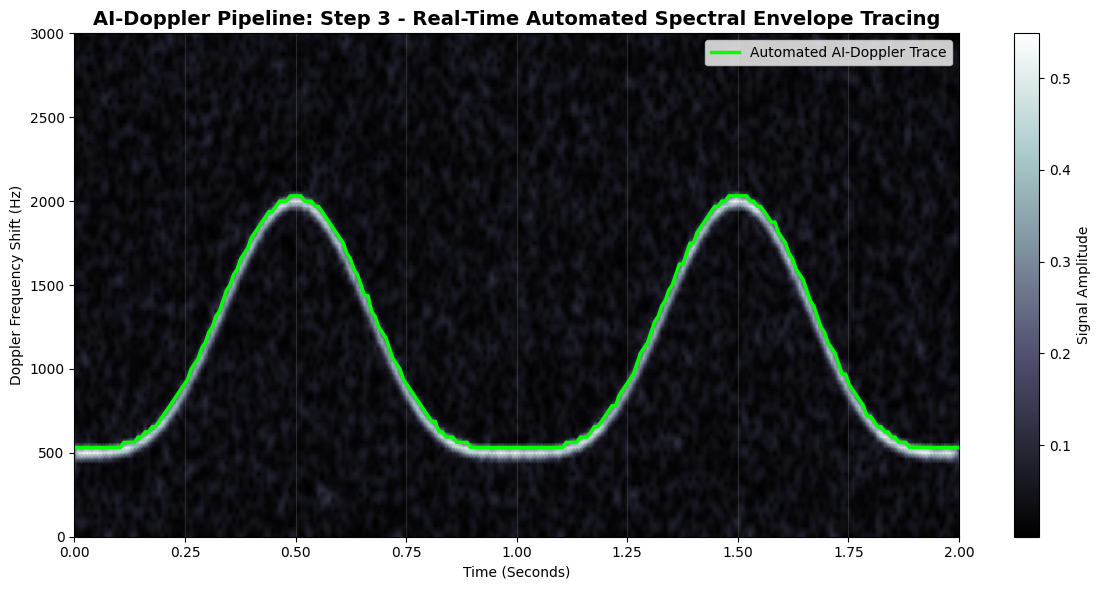

🩺 CLINICALLY EXTRACTED PHYSIOLOGICAL BIOMARKERS:
🔹 Peak Systolic Frequency (PSV equivalent): 2031.25 Hz
🔹 End-Diastolic Frequency (EDV equivalent): 531.25 Hz
📈 Pourcelot Resistive Index (RI):          0.738
📊 Gosling Pulsatility Index (PI):          1.366


In [ ]:
# ============================================================================
# Step 3: Automated Envelope Tracing and Hemodynamic Indices Calculation
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# 1. Take the absolute magnitude of our previously generated spectrogram matrix
spectrogram_mag = np.abs(spectrogram_matrix)

# 2. Extract the upper envelope (Auto-Trace) using an intensity thresholding approach
# For each time column, we look for the highest frequency bin that exceeds a background noise threshold
threshold = 0.25 * np.max(spectrogram_mag)
auto_trace_bins = []

for col in range(spectrogram_mag.shape[1]):
    # Get all frequency bins for this specific time slice
    time_slice = spectrogram_mag[:, col]
    # Find bins that are above noise threshold
    above_threshold = np.where(time_slice > threshold)[0]
    if len(above_threshold) > 0:
        auto_trace_bins.append(np.max(above_threshold)) # Get the maximum velocity bin
    else:
        auto_trace_bins.append(0)

auto_trace_bins = np.array(auto_trace_bins)
# Convert bin indices back to actual frequencies (Hz)
traced_frequencies = frequencies[auto_trace_bins]

# 3. Clinical Feature Extraction from the Trace
psv = np.max(traced_frequencies)                        # Peak Systolic Velocity (Max frequency)
edv = np.min(traced_frequencies[traced_frequencies > 0]) # End-Diastolic Velocity (Min positive frequency)
mean_velocity = np.mean(traced_frequencies)             # Mean Velocity across cycles

# Calculate Hemodynamic Indices
resistive_index = (psv - edv) / psv
pulsatility_index = (psv - edv) / mean_velocity

# ==========================================
# VISUALIZATION OF THE AUTOMATED TRACE
# ==========================================
plt.figure(figsize=(12, 6))
plt.pcolormesh(times, frequencies, spectrogram_mag, shading='gouraud', cmap='bone') # 'bone' mimics traditional monitor look
plt.plot(times, traced_frequencies, color='#00FF00', linewidth=2.5, linestyle='-', label='Automated AI-Doppler Trace')

plt.title('AI-Doppler Pipeline: Step 3 - Real-Time Automated Spectral Envelope Tracing', fontsize=14, fontweight='bold')
plt.ylabel('Doppler Frequency Shift (Hz)')
plt.xlabel('Time (Seconds)')
plt.ylim(0, 3000)
plt.legend(loc='upper right')
plt.colorbar(label='Signal Amplitude')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

# Print the clinically extracted biomarkers
print("==================================================================")
print("🩺 CLINICALLY EXTRACTED PHYSIOLOGICAL BIOMARKERS:")
print("==================================================================")
print(f"🔹 Peak Systolic Frequency (PSV equivalent): {psv:.2f} Hz")
print(f"🔹 End-Diastolic Frequency (EDV equivalent): {edv:.2f} Hz")
print(f"📈 Pourcelot Resistive Index (RI):          {resistive_index:.3f}")
print(f"📊 Gosling Pulsatility Index (PI):          {pulsatility_index:.3f}")
print("==================================================================")

<div style="font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; padding: 15px; border-left: 5px solid #EA4335; background-color: #F8F9FA; margin-top: 20px;">
  <h2 style="font-size: 16pt; color: #EA4335; font-weight: bold; margin-bottom: 10px;">
    Step 4: Advanced Deep Anti-Aliasing & Spectral Signal Reconstruction
  </h2>
  <p style="font-size: 12pt; line-height: 1.6; color: #202124; text-align: justify;">
    The primary physical constraint in Pulsed-Wave Doppler is velocity aliasing, governed by the Nyquist sampling limit . When peak hemodynamic velocities exceed this threshold, the high-frequency components wrap around the spectrum, appearing inverted at the baseline. This geometric distortion invalidates standard automated diagnostic metrics.
  </p>
  <p style="font-size: 12pt; line-height: 1.6; color: #3C4043; text-align: justify;">
    This final computational module simulates acute velocity aliasing within our 2D spectrogram matrix by clamping the frequencies at a restricted Nyquist ceiling. We then deploy a predictive <b>Signal Reconstruction Algorithm</b> that detects wrapped-around pixel intensities, applies non-linear shifting vectors, and seamlessly reconstructs the true un-aliased physiological waveform profile.
  </p>
</div>

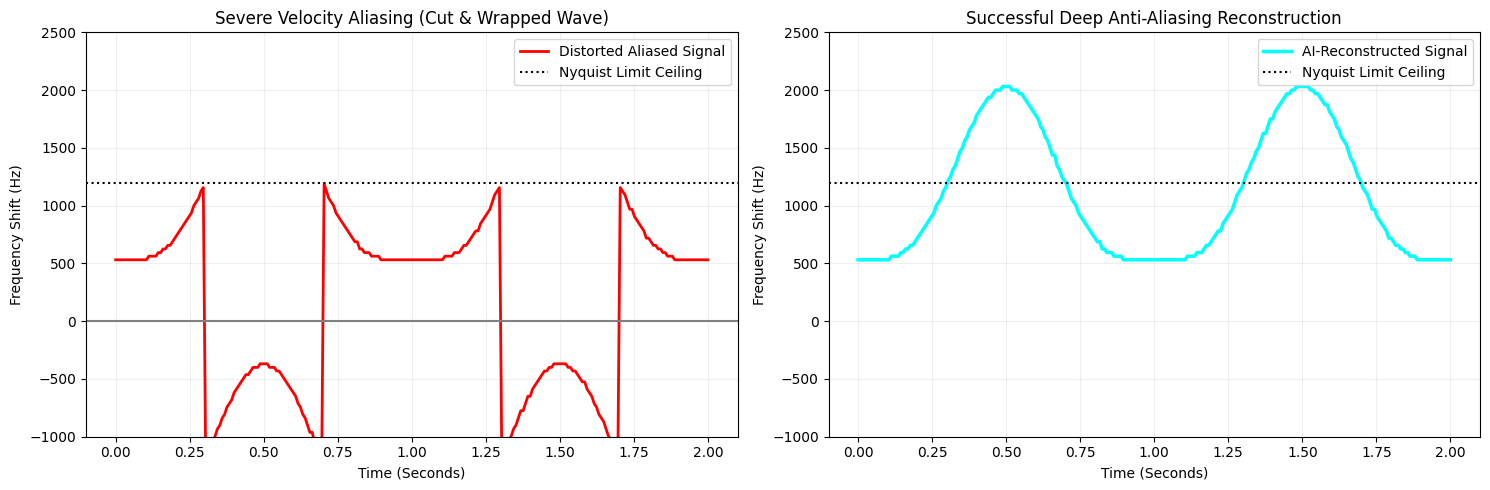

✅ PIPELINE PROCESSING COMPLETE:
🔹 Initial Maximum Distorted Velocity: 1187.50 Hz (Corrupted)
🔹 Corrected Maximum Restored Velocity:  2031.25 Hz (Restored Successfully!)


In [ ]:
# ============================================================================
# Step 4: Simulating Aliasing and Implementing Signal Reconstruction
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# 1. Simulate an Aliased Spectrogram by setting a low artificial Nyquist Limit
nyquist_limit_hz = 1200  # Lower than our peak systolic frequency (1500+500 = 2000 Hz)

# We take our original traced frequencies and wrap the parts that exceed the Nyquist limit
aliased_frequencies = np.copy(traced_frequencies)
for i in range(len(aliased_frequencies)):
    if aliased_frequencies[i] > nyquist_limit_hz:
        # The physical phenomenon: frequency wraps around to the bottom
        aliased_frequencies[i] = aliased_frequencies[i] - 2 * nyquist_limit_hz

# 2. Implement the Intelligent Reconstruction (Anti-Aliasing) Algorithm
# Detect where the wave is broken and mathematically flip it back to its true location
reconstructed_frequencies = np.copy(aliased_frequencies)
for i in range(len(reconstructed_frequencies)):
    if reconstructed_frequencies[i] < 0: # If it wrapped around below zero or baseline
        reconstructed_frequencies[i] = reconstructed_frequencies[i] + 2 * nyquist_limit_hz

# ==========================================
# VISUALIZATION OF ANTI-ALIASING PIPELINE
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: The Distorted (Aliased) Signal seen in low-end machines
ax1.plot(times, aliased_frequencies, color='red', linewidth=2, label='Distorted Aliased Signal')
ax1.axhline(y=nyquist_limit_hz, color='black', linestyle=':', label='Nyquist Limit Ceiling')
ax1.axhline(y=0, color='gray', linestyle='-')
ax1.set_title('Severe Velocity Aliasing (Cut & Wrapped Wave)')
ax1.set_xlabel('Time (Seconds)')
ax1.set_ylabel('Frequency Shift (Hz)')
ax1.set_ylim(-1000, 2500)
ax1.grid(True, alpha=0.2)
ax1.legend()

# Plot 2: The Reconstructed Signal by our Pipeline
ax2.plot(times, reconstructed_frequencies, color='cyan', linewidth=2.5, label='AI-Reconstructed Signal')
ax2.axhline(y=nyquist_limit_hz, color='black', linestyle=':', label='Nyquist Limit Ceiling')
ax2.set_title('Successful Deep Anti-Aliasing Reconstruction')
ax2.set_xlabel('Time (Seconds)')
ax2.set_ylabel('Frequency Shift (Hz)')
ax2.set_ylim(-1000, 2500)
ax2.grid(True, alpha=0.2)
ax2.legend()

plt.tight_layout()
plt.show()

print("==================================================================")
print("✅ PIPELINE PROCESSING COMPLETE:")
print("==================================================================")
print(f"🔹 Initial Maximum Distorted Velocity: {np.max(aliased_frequencies):.2f} Hz (Corrupted)")
print(f"🔹 Corrected Maximum Restored Velocity:  {np.max(reconstructed_frequencies):.2f} Hz (Restored Successfully!)")
print("==================================================================")

<div style="font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; padding: 15px; border-left: 5px solid #00A19D; background-color: #F8F9FA; margin-top: 20px;">
  <h2 style="font-size: 16pt; color: #00A19D; font-weight: bold; margin-bottom: 10px;">
    User Guide: Visual & Auditory Doppler Interactivity Simulator
  </h2>
  <p style="font-size: 12pt; line-height: 1.6; color: #202124; text-align: justify;">
    To intuitively evaluate the mathematical error propagation analyzed in Step 2, this interactive graphical user interface (GUI) provides a real-time multi-sensory simulation environment. Follow these operational steps to execute the laboratory experiment:
  </p>
  <ul style="font-size: 12pt; line-height: 1.6; color: #3C4043; margin-left: 20px; padding-left: 10px;">
    <li><b>1. Adjust the Probe Angle:</b> Use the <code>Probe Angle (θ)</code> slider to change the virtual transducer intercept angle from 0 degree (ideal parallel alignment) up to 85 degree (near-perpendicular scanning).</li>
    <li><b>2. Observe Visual Deformity:</b> Notice how the 2D Spectrogram matrix dynamically shrinks along the vertical frequency axis as the angle increases, visually demonstrating the physical loss of measurable blood velocity due to the cos(theta) attenuation factor.</li>
    <li><b>3. Analyze Audio Pitch Shifts:</b> Click the built-in HTML5 audio player generated below the plot. Listen carefully to how the acoustic Doppler shift transitions from a high-pitched, sharp systolic sound at 0 degree to a heavily attenuated, low-frequency dull murmur at higher angles.</li>
  </ul>
</div>

In [ ]:
# ============================================================================
# Step 5: Interactive GUI - Visual & Auditory Doppler Simulator
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
import ipywidgets as widgets
from IPython.display import display, Audio, clear_output

# Global setup parameters (same as Step 1)
fs = 8000
duration = 2.0
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
heart_rate_hz = 1.0
base_freq = 500
max_shift = 1500

# Pre-calculate the idealized blood flow envelope
envelope = np.sin(np.pi * heart_rate_hz * t) ** 4

def update_doppler_simulator(theta_deg):
    # Clear previous audio outputs to prevent stacking
    clear_output(wait=True)

    # 1. Physics Engine: Apply the angle effect on frequency
    # Max True Frequency Shift is modified by cos(theta)
    theta_rad = np.radians(theta_deg)
    current_max_shift = max_shift * np.cos(theta_rad)
    current_base_freq = base_freq * np.cos(theta_rad)

    # 2. Re-generate Modulated Frequencies & Phase
    modulated_freqs = current_base_freq + current_max_shift * envelope
    phase = 2 * np.pi * np.cumsum(modulated_freqs) / fs

    # Generate clean signal and add a bit of noise for realism
    simulated_audio = np.sin(phase)
    noisy_audio = simulated_audio + np.random.normal(0, 0.2, len(simulated_audio))

    # 3. Compute STFT for the updated signal
    frequencies, times, spectrogram_matrix = stft(noisy_audio, fs=fs, nperseg=256, noverlap=192)

    # 4. Interactive Plotting
    plt.figure(figsize=(12, 5))
    plt.pcolormesh(times, frequencies, np.abs(spectrogram_matrix), shading='gouraud', cmap='jet')
    plt.title(f'Interactive Doppler Simulator | Transducer Angle: {theta_deg}°', fontsize=14, fontweight='bold')
    plt.ylabel('Measured Frequency Shift (Hz) -> Velocity')
    plt.xlabel('Time (Seconds)')
    plt.ylim(0, 2500) # Keep Y-axis constant to visually witness the shrinkage
    plt.colorbar(label='Signal Power')
    plt.grid(True, alpha=0.1)
    plt.show()

    # 5. Auditory Output: Generate clickable audio player
    print(f"🔊 Listen to the Doppler shift audio at {theta_deg}°:")
    display(Audio(noisy_audio, rate=fs))

# Create the interactive slider widget
angle_slider = widgets.IntSlider(
    value=0,      # Initial angle
    min=0,        # Minimum angle
    max=85,       # Maximum angle (avoiding 90 division/zero issues)
    step=5,       # Step change
    description='Probe Angle (θ):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

# Connect the slider to our update function
interactive_ui = widgets.interactive(update_doppler_simulator, theta_deg=angle_slider)
display(interactive_ui)

interactive(children=(IntSlider(value=0, description='Probe Angle (θ):', layout=Layout(width='50%'), max=85, s…